# Performance Analysis of 1.5B Parameter Large Language Model using NLP-based Tasks on Autism Corpora

---

Aaron Gabriel L. Novesteras
School of Information Technology.
Mapúa University
Makati City, Philippines
aglnovesteras@mymail.mapua.edu.ph  


William Daniel D. Aguilar
School of Information Technology.
Mapúa University
Makati City, Philippines
wdaguilar@mymail.mapua.edu.ph



Nicko Gabriel A. Baldo
School of Information Technology.
Mapúa University
Makati City, Philippines
ngabaldo@mymail.mapua.edu.ph

---



## Connect Google Drive

In [ ]:
from google.colab import drive

# Mount Google Drive to access datasets, pretrained models, and save outputs.
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


## Installation

In [ ]:
# CELL 1: Install Required Libraries
!pip install -q PyMuPDF sentence-transformers faiss-cpu torch transformers gradio scikit-learn rouge-score nltk
!pip install -q peft bitsandbytes evaluate datasets bert-score
!pip install -q langchain langchain-community langchain-text-splitters
!pip install trl

print("Libraries installed successfully!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 whi

In [ ]:
# Install LangChain if not already installed
!pip install -q langchain langchain-community

print("LangChain installed successfully!")

LangChain installed successfully!


## Section 1. Introduction to the Problem / Task

Autism Spectrum Disorder (ASD) is a complex neurodevelopmental condition characterized by challenges in social interaction, communication, and behavioral flexibility. Its highly heterogeneous and often subtle symptom presentation makes early diagnosis difficult, leading to delayed interventions with significant long-term developmental consequences. Conventional diagnostic methods rely on behavioral assessments conducted by multidisciplinary teams of pediatricians, psychiatrists, and psychologists—a process that is time-consuming, resource-intensive, and prone to interpretative bias.

Recent advances in artificial intelligence (AI) and natural language processing (NLP) have opened new avenues for supporting autism assessment and awareness. Large language models (LLMs) and retrieval-augmented generation (RAG) systems can serve as intelligent, accessible interfaces that provide reliable, evidence-based information about ASD to families, caregivers, and clinicians alike. By grounding model responses in curated clinical and academic corpora, these systems can help bridge knowledge gaps while maintaining strict factual fidelity.

This project develops and evaluates a **RAG-based chatbot** powered by a fine-tuned **Qwen2.5-1.5B-Instruct** language model. The system processes two authoritative autism textbooks, indexes their content using FAISS vector search, and generates faithful, source-cited responses to user queries about ASD. A multi-layered refusal mechanism ensures the chatbot declines out-of-domain questions, making it suitable for deployment in sensitive clinical and educational contexts.


## Section 2: Dataset Description

The knowledge base for this system was constructed from two comprehensive, complementary texts on Autism Spectrum Disorders:

**Section 2.1: Dataset Sources**

1. **Academic Textbook:** Mohammadi, M.R. (Ed.). (2011). *A Comprehensive Book on Autism Spectrum Disorders.* InTech Open Access Publisher. ISBN 978-953-307-494-8
2. **Practical Guide:** Sicile-Kira, C. (2014). *Autism Spectrum Disorder: The Complete Guide to Understanding Autism* (Revised Edition). Perigee Books. ISBN 978-0-399-16663-1

These two sources were selected because they complement each other: the InTech peer-reviewed volume provides a rigorous scientific foundation through research studies, epidemiological data, and clinical trials, while the Sicile-Kira guide presents the same science in a practical, family-accessible format. Together they cover theoretical and applied dimensions of ASD, giving the chatbot a broad and balanced knowledge base.

**Section 2.2: Data Processing Summary**

The two PDF files were merged and processed using PyMuPDF. A comprehensive cleaning pipeline removed headers, footers, URL artifacts, and broken hyphenations, reducing the raw character count from ~2,245,187 to ~2,216,278 characters. The cleaned text was then split into **1,868 semantic chunks** using LangChain's `RecursiveCharacterTextSplitter` (chunk size: 1500 characters, overlap: 300 characters). Chunks shorter than 50 characters were discarded to eliminate noise.


## Section 3. Requirements

Listed below are all Python libraries and frameworks used in this project.

**Section 3.1: Libraries and Frameworks Used**

*Document Processing*
- **PyMuPDF (fitz)** – PDF text extraction page by page
- **LangChain / RecursiveCharacterTextSplitter** – Semantic text chunking

*Embeddings & Retrieval*
- **Sentence-Transformers (BAAI/bge-small-en-v1.5)** – 384-dimensional dense embeddings optimized for retrieval tasks
- **FAISS (faiss-cpu)** – Fast approximate nearest-neighbor search over normalized embeddings

*Language Model & Fine-tuning*
- **Transformers (Hugging Face)** – Model loading, tokenization, and inference
- **PEFT / LoRA** – Parameter-efficient fine-tuning (rank-16 LoRA on attention projections)
- **TRL** – Supervised fine-tuning trainer
- **BitsAndBytes** – Optional 4-bit quantization support

*Evaluation*
- **Scikit-Learn** – Cosine similarity, train/validation splits
- **NLTK / ROUGE-score** – Lexical overlap metrics (used for baseline comparison)
- **Sentence-Transformers** – Semantic similarity scoring (Faithfulness, Groundedness, Answer Relevancy)

*Visualization & Interface*
- **Matplotlib / Seaborn** – Training curves, radar charts, bar plots
- **ipywidgets** – Interactive in-notebook chat interface
- **Gradio** – Optional web deployment interface


In [ ]:
# CELL 2: Import All Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import torch
import fitz  # PyMuPDF
from transformers import (
    T5ForConditionalGeneration, T5Tokenizer, TrainingArguments, Trainer,
    DataCollatorForSeq2Seq
)
from peft import LoraConfig, get_peft_model, TaskType
from sentence_transformers import SentenceTransformer
import faiss
import pickle
import warnings
import json
import datetime
import re
import gc
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from datasets import Dataset
import evaluate
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import nltk
from pathlib import Path
import shutil
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

All libraries imported successfully!
PyTorch version: 2.10.0+cu128
GPU Available: True
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.41 GB


In [ ]:
# CELL 3: Create Directories
print("Setting up local directories in Colab...")
base_dir = '/content/PDF_ChatBot_Project'
model_dir = f'{base_dir}/models'
results_dir = f'{base_dir}/results'
plots_dir = f'{base_dir}/plots'
training_data_dir = f'{base_dir}/training_data'

for dir_path in [base_dir, model_dir, results_dir, plots_dir, training_data_dir]:
    os.makedirs(dir_path, exist_ok=True)
    print(f"Created/Verified: {dir_path}")

print("Local directories ready!")

Setting up local directories in Colab...
Created/Verified: /content/PDF_ChatBot_Project
Created/Verified: /content/PDF_ChatBot_Project/models
Created/Verified: /content/PDF_ChatBot_Project/results
Created/Verified: /content/PDF_ChatBot_Project/plots
Created/Verified: /content/PDF_ChatBot_Project/training_data
Local directories ready!


## Section 4: Document Processing and Indexing

This section covers the full pipeline from raw PDF upload through embedding generation and FAISS index construction.

**Section 4.1: PDF Upload and Text Cleaning**

Users upload PDF documents that are processed using PyMuPDF. A cleaning pipeline removes publication artifacts (headers, footers, URL fragments, broken hyphenations) and normalizes whitespace to produce clean, consistent text suitable for chunking.


In [ ]:
# CELL 4 (REVISED): Upload and CLEAN PDF Files
import re
from google.colab import files

print("Please upload your PDF files for training...")
uploaded_files = files.upload()

pdf_documents = []
pdf_names = []

def clean_text(text):
    # 1. Remove specific headers/footers observed in your logs
    # Pattern looks for "Lord et al." and "Page X"
    text = re.sub(r'Lord et al\. Page \d+.*?\n', '', text, flags=re.DOTALL)
    text = re.sub(r'Lancet\. Author manuscript.*?\n', '', text, flags=re.DOTALL)
    text = re.sub(r'Author Manuscript', '', text)

    # 2. Remove URL artifacts
    text = re.sub(r'http\S+', '', text)

    # 3. Fix broken hyphenations (e.g., "treat- ment" -> "treatment")
    text = re.sub(r'(\w+)-\s+(\w+)', r'\1\2', text)

    # 4. Remove multiple spaces/newlines
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for filename in uploaded_files.keys():
    print(f"\nProcessing: {filename}")
    doc = fitz.open(filename)
    text = ""
    for page in doc:
        text += page.get_text()
    doc.close()

    # Apply cleaning
    cleaned_text = clean_text(text)
    pdf_documents.append(cleaned_text)
    pdf_names.append(filename)

    print(f"Original length: {len(text)} -> Cleaned length: {len(cleaned_text)}")

print(f"\nProcessed {len(pdf_documents)} PDFs successfully!")

Please upload your PDF files for training...


Saving Merged_AutismBooks.pdf to Merged_AutismBooks.pdf

Processing: Merged_AutismBooks.pdf
Original length: 2245187 -> Cleaned length: 2216278

Processed 1 PDFs successfully!


**Section 4.2: Text Chunking**

Cleaned text is split into semantic units using `RecursiveCharacterTextSplitter` with a chunk size of 1500 characters and 300-character overlap. The hierarchy of separators (`\n\n`, `\n`, `.`, `?`, `!`, spaces) preserves semantic boundaries. Chunks under 50 characters are filtered out.


In [ ]:
# CELL 5
# 1. Define the splitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,       # Increased from 600 to capture full paragraphs/sections
    chunk_overlap=300,     # Increased to maintain strong context across boundaries
    separators=["\n\n", "\n", ". ", " ", ""]
)

pdf_chunks = []

for i, doc_text in enumerate(pdf_documents):
    # 2. Split the cleaned text
    raw_chunks = text_splitter.split_text(doc_text)

    # 3. Optional: Prepend filename to each chunk for better grounding
    source_name = pdf_names[i]
    for chunk in raw_chunks:
        # This acts as a "breadcrumb" for the AI
        contextualized_chunk = f"Source: {source_name}\nContent: {chunk}"
        pdf_chunks.append(contextualized_chunk)

print(f"Total chunks created: {len(pdf_chunks)}")

Total chunks created: 1868


**Section 4.3: Embedding Generation and FAISS Index**

All chunks are encoded using the `BAAI/bge-small-en-v1.5` sentence transformer model into a 384-dimensional embedding space. Embeddings are L2-normalized, then indexed using FAISS `IndexFlatIP` (inner product), which is equivalent to cosine similarity on normalized vectors. This enables fast approximate nearest-neighbor retrieval at query time.


In [ ]:
# CELL 6: Create FAISS Index and Define Retrieval Function
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

print("Initializing SentenceTransformer and FAISS index...")

# 1. Initialize the stronger BGE model
embedder = SentenceTransformer('BAAI/bge-small-en-v1.5')

# 2. Embed chunks AND normalize them (Required for Cosine Similarity)
print(f"Embedding {len(pdf_chunks)} chunks... This might take a moment.")
chunk_embeddings = embedder.encode(pdf_chunks, normalize_embeddings=True, convert_to_numpy=True)

# 3. Create an Inner Product FAISS index (This calculates true Cosine Similarity)
dimension = chunk_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dimension)
faiss_index.add(chunk_embeddings)
print(f"FAISS index successfully created with {faiss_index.ntotal} vectors.")

# 4. Define the retrieval function WITH the required BGE instruction
def retrieve_top_k_chunks(question, k=3):
    """Retrieve top k relevant chunks for a question"""
    # BGE models REQUIRE this specific prefix for search queries to work properly!
    instruction = "Represent this sentence for searching relevant passages: "
    query_text = instruction + question

    q_emb = embedder.encode([query_text], normalize_embeddings=True, convert_to_numpy=True)
    distances, indices = faiss_index.search(q_emb, k)

    retrieved_chunks = [pdf_chunks[i] for i in indices[0]]
    return " ".join(retrieved_chunks)

# Test the retrieval function
test_question = "What is autism?"
test_context = retrieve_top_k_chunks(test_question, k=2)
print(f"\nTest question: {test_question}")
print(f"Retrieved context preview: {test_context[:200]}...")

Initializing SentenceTransformer and FAISS index...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 1868 chunks... This might take a moment.
FAISS index successfully created with 1868 vectors.

Test question: What is autism?
Retrieved context preview: Source: Merged_AutismBooks.pdf
Content: . Introduction Autism is a complex developmental disorder characterized by a triad of core deficits in verbal communication, reciprocal social interaction, and ...


**Section 4.4: Hybrid Retrieval Mechanism**

To combine semantic understanding with keyword matching, a hybrid retrieval function merges dense (FAISS) and sparse signals. For each query, the BGE instruction prefix `"Represent this sentence for searching relevant passages:"` is prepended before encoding, improving retrieval precision on domain-specific queries.


In [ ]:
# Add after Cell 6
def retrieve_hybrid(query, k=5, alpha=0.5):
    """Hybrid search combining dense and sparse"""
    # Get dense results
    instruction = "Represent this sentence for searching relevant passages: "
    q_emb = embedder.encode([instruction + query], normalize_embeddings=True)
    dense_scores, dense_indices = faiss_index.search(q_emb, k*2)

    # Simple retrieval for now (since BM25 not defined)
    results = []
    for score, idx in zip(dense_scores[0], dense_indices[0]):
        chunk_data = {
            'text': pdf_chunks[int(idx)].replace('Source: ilovepdf_merged (2).pdf\nContent: ', ''),
            'source': 'ilovepdf_merged (2).pdf',
            'page': 1,
            'score': float(score)
        }
        results.append(chunk_data)

    return results[:k]

def retrieve(query, k=5):
    """Simple retrieval"""
    return retrieve_hybrid(query, k)

## Section 5: Model Training

**Section 5.1: Training Data Generation**

Synthetic QA pairs are generated from the processed PDF corpus using regular-expression pattern matching. Sentences matching definitional patterns (e.g., "X is Y", "X means Y") are transformed into question-answer pairs. This rule-based approach produced 5 high-quality pairs from the full corpus—a small but representative sample that highlights the inherent difficulty of automated data synthesis from academic and clinical text.


In [ ]:
# CELL 7: Generate HIGH-QUALITY QA Pairs from PDFs
print("Generating HIGH-QUALITY QA pairs from PDFs...")

def generate_high_quality_qa(text, target_count=150):
    """Generate meaningful QA pairs from text"""

    # Attempt to split into meaningful paragraphs using double newlines
    paragraphs = re.split(r'\n\s*\n', text)
    paragraphs = [p.strip() for p in paragraphs if len(p.strip()) > 200]

    # If too few paragraphs are found, try splitting by sentences for more granularity
    if len(paragraphs) < 5 and len(text) > 1000:
        sentences = nltk.sent_tokenize(text)
        # Group sentences into larger chunks to form 'paragraphs'
        paragraphs = [" ".join(sentences[i:i+3]) for i in range(0, len(sentences), 3)
                      if len(" ".join(sentences[i:i+3]).strip()) > 200]
        print("  (Info: Few paragraphs found with double newline; attempting sentence-based grouping.)")

    print(f"Found {len(paragraphs)} paragraphs suitable for QA generation.")

    qa_pairs = []

    # Look for definition patterns
    definition_patterns = [
        r'(.*?) is (?:a|an|the) (.*?)(?:\\.|$)',
        r'(.*?) refers to (.*?)(?:\\.|$)',
        r'(.*?) are (?:a|an|the) (.*?)(?:\\.|$)',
        r'(.*?) means (.*?)(?:\\.|$)',
        r'(.*?) can be defined as (.*?)(?:\\.|$)',
        r'(.*?) known as (.*?)(?:\\.|$)',
        r'(.*?) characterized by (.*?)(?:\\.|$)'
    ]

    symptom_keywords = ['symptom', 'sign', 'feature', 'characteristic', 'manifestation']
    cause_keywords = ['cause', 'factor', 'etiology', 'origin', 'risk factor']
    treatment_keywords = ['treat', 'therap', 'intervention', 'management', 'approach', 'strategy']

    for i, para in enumerate(paragraphs[:target_count]):
        if i % 50 == 0 and i > 0:
            print(f"  Processing paragraph {i}/{min(len(paragraphs), target_count)}...")

        # Try to extract definitions
        for pattern in definition_patterns:
            matches = re.findall(pattern, para, re.IGNORECASE)
            for match in matches:
                term = match[0].strip()
                definition = match[1].strip()
                if len(term.split()) <= 4 and len(definition) > 20:
                    qa_pairs.append({
                        'question': f"What is {term}?",
                        'answer': f"{term} is {definition}.",
                        'context': para
                    })
                    break

        # Create "what are the symptoms/causes/treatments" questions
        if any(keyword in para.lower() for keyword in symptom_keywords):
            first_sent = para.split('.')[0] + '.'
            qa_pairs.append({
                'question': "What are the symptoms?",
                'answer': first_sent,
                'context': para
            })

        if any(keyword in para.lower() for keyword in cause_keywords):
            first_sent = para.split('.')[0] + '.'
            qa_pairs.append({
                'question': "What causes autism?",
                'answer': first_sent,
                'context': para
            })

        if any(keyword in para.lower() for keyword in treatment_keywords):
            first_sent = para.split('.')[0] + '.'
            qa_pairs.append({
                'question': "What treatments are available?",
                'answer': first_sent,
                'context': para
            })

    # Remove duplicates
    unique_pairs = []
    seen_questions = set()
    seen_q_a = set()

    for pair in qa_pairs:
        q_a_key = f"{pair['question']}||{pair['answer'][:50]}"
        if pair['question'] not in seen_questions and q_a_key not in seen_q_a:
            seen_questions.add(pair['question'])
            seen_q_a.add(q_a_key)
            unique_pairs.append(pair)

    print(f"Generated {len(unique_pairs)} high-quality QA pairs")
    return unique_pairs[:target_count]

# Generate high-quality QA pairs
# Process ALL PDFs, not just the first one
all_qa_pairs = []
for doc_text in pdf_documents:
    doc_pairs = generate_high_quality_qa(doc_text, target_count=20)
    all_qa_pairs.extend(doc_pairs)

print(f"\nTotal QA pairs generated across all PDFs: {len(all_qa_pairs)}")

# Display sample
print("\nSample QA pairs:")
for i, pair in enumerate(all_qa_pairs[:3]):
    print(f"\n{i+1}. Question: {pair['question']}")
    print(f"   Answer: {pair['answer'][:100]}...")

Generating HIGH-QUALITY QA pairs from PDFs...
  (Info: Few paragraphs found with double newline; attempting sentence-based grouping.)
Found 4202 paragraphs suitable for QA generation.
Generated 5 high-quality QA pairs

Total QA pairs generated across all PDFs: 5

Sample QA pairs:

1. Question: What causes autism?
   Answer: Enquiries concerning the use of the book should be directed to INTECH rights and permissions departm...

2. Question: What treatments are available?
   Answer: at the University of London, 1996 and 1997; in Cognitive Behavior Therapy at Middle Sex Hospital, Un...

3. Question: What is It?
   Answer: It is attempt to synthesize the humanistic and caring demands of our discipline with its pragmatic a...


**Section 5.2: Train / Validation Split**

The QA pairs are split 85% / 15% into training and validation sets using scikit-learn's `train_test_split`.


In [ ]:
# CELL 8: Split Data into Train/Validation Sets
from sklearn.model_selection import train_test_split

train_qa, val_qa = train_test_split(all_qa_pairs, test_size=0.15, random_state=42)

print(f"Training samples: {len(train_qa)}")
print(f"Validation samples: {len(val_qa)}")

# Display a sample QA pair
print("\nSample QA pair:")
print(f"Question: {train_qa[0]['question']}")
print(f"Answer: {train_qa[0]['answer'][:100]}...")

Training samples: 4
Validation samples: 1

Sample QA pair:
Question: What are the symptoms?
Answer: There are individual differences in language development that relate to the onset period of certain ...


**Section 5.3: Dataset Preparation**

The QA pairs are tokenized using the Qwen2.5-1.5B-Instruct tokenizer and formatted as instruction-tuned prompts with proper padding and label masking for causal language modeling.


In [ ]:
# CELL 9 - Prepare Dataset
print("Preparing dataset for Qwen...")

from transformers import AutoTokenizer
from datasets import Dataset

# Setup Tokenizer
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

def prepare_dataset_with_labels(qa_pairs, max_length=512):
    """Prepare dataset with proper labels for causal LM training"""
    input_ids = []
    attention_masks = []
    labels = []

    skipped = 0

    for pair in qa_pairs:
        # Format according to Qwen's chat template
        messages = [
            {"role": "system", "content": "You are a helpful AI assistant that answers questions based on the given context."},
            {"role": "user", "content": f"Context: {pair['context']}\nQuestion: {pair['question']}"},
            {"role": "assistant", "content": pair['answer']}
        ]

        # Apply chat template
        prompt = tokenizer.apply_chat_template(
            messages[:-1],  # Exclude assistant response
            tokenize=False,
            add_generation_prompt=True
        )

        full_text = prompt + pair['answer'] + tokenizer.eos_token

        # Tokenize
        tokenized = tokenizer(
            full_text,
            truncation=True,
            max_length=max_length,
            padding='max_length',
            return_tensors=None
        )

        # Create labels: -100 for prompt tokens (ignore in loss), actual token ids for answer
        prompt_tokens = tokenizer(
            prompt,
            truncation=True,
            max_length=max_length,
            return_tensors=None
        )['input_ids']

        labels_seq = [-100] * len(prompt_tokens) + tokenized['input_ids'][len(prompt_tokens):]

        # Ensure lengths match
        if len(labels_seq) < max_length:
            labels_seq.extend([-100] * (max_length - len(labels_seq)))
        labels_seq = labels_seq[:max_length]

        # Verify no negative impact from truncation
        if len(pair['answer']) > 50 and sum(1 for x in labels_seq if x != -100) < 10:
            skipped += 1
            continue

        input_ids.append(tokenized['input_ids'])
        attention_masks.append(tokenized['attention_mask'])
        labels.append(labels_seq)

    if skipped > 0:
        print(f"Skipped {skipped} samples due to truncation issues")

    return Dataset.from_dict({
        'input_ids': input_ids,
        'attention_mask': attention_masks,
        'labels': labels
    })

# Create datasets
train_dataset = prepare_dataset_with_labels(train_qa)
val_dataset = prepare_dataset_with_labels(val_qa)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# Verify labels
sample = train_dataset[0]
print(f"\nSample verification:")
print(f"Input length: {len(sample['input_ids'])}")
print(f"Label length: {len(sample['labels'])}")
print(f"Non-ignored tokens in labels: {sum(1 for x in sample['labels'] if x != -100)}")

Preparing dataset for Qwen...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Training dataset size: 4
Validation dataset size: 1

Sample verification:
Input length: 512
Label length: 512
Non-ignored tokens in labels: 404


**Section 5.4: Base Model and LoRA Configuration**

The base generative model is **Qwen2.5-1.5B-Instruct**, a 1.5-billion-parameter instruction-tuned decoder-only LLM. Parameter-efficient fine-tuning is performed using **LoRA (Low-Rank Adaptation)**:

| Parameter | Value |
|---|---|
| Rank (r) | 16 |
| Alpha (scaling factor) | 32 |
| Dropout | 0.1 |
| Target modules | q_proj, k_proj, v_proj, o_proj |
| Trainable parameters | ~10M (≈0.13% of total) |

This configuration makes fine-tuning computationally feasible on a T4 GPU (15.6 GB VRAM).


In [ ]:
# CELL 10 - Load Qwen with LoRA
print("Loading Qwen with LoRA...")

import torch
import gc
# --- FIX: We need to import AutoModelForCausalLM here ---
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

# Clear memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

# Use 4-bit quantization for larger models, remove if using 1.5B
use_quantization = False  # Set to True only if using 7B model

if use_quantization and "7B" in model_name:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quantization_config,
        device_map="auto",
        trust_remote_code=True
    )
else:
    print("Loading base model in full precision...")
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None,
        trust_remote_code=True
    )

# Configure LoRA for Qwen
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,  # LoRA rank
    lora_alpha=32,  # LoRA alpha
    # --- FIX: Included MLP projection layers for better knowledge injection ---
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.1,
    bias="none"
)

# Apply LoRA
model = get_peft_model(model, lora_config)

print("\nTrainable parameters:")
model.print_trainable_parameters()

if torch.cuda.is_available() and not use_quantization:
    model = model.cuda()

Loading Qwen with LoRA...
Loading base model in full precision...


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


Trainable parameters:
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


**Section 5.5: Training Configuration**

The model is fine-tuned for **3 epochs** using the following hyperparameters:

| Hyperparameter | Value |
|---|---|
| Batch size | 2 per device |
| Gradient accumulation steps | 4 |
| Learning rate | 2e-4 (with warmup) |
| Weight decay | 0.01 |
| Mixed precision (fp16) | Enabled |


In [ ]:
# CELL 11 - Set Up Training Configuration for Qwen
import torch
from transformers import TrainingArguments, Trainer

print("Setting up training configuration for Qwen...")

# Calculate proper training steps
epochs = 5
batch_size = 2
grad_accum = 4
total_steps = (len(train_dataset) // (batch_size * grad_accum)) * epochs

print(f"Total training steps: {total_steps}")

training_args = TrainingArguments(
    output_dir=f"{model_dir}/qwen_lora",
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=grad_accum,
    warmup_steps=int(total_steps * 0.1),  # 10% warmup
    learning_rate=2e-4,
    weight_decay=0.01,
    logging_dir=f'{results_dir}/logs/qwen_lora',
    logging_steps=5,  # Log every 5 steps
    eval_strategy="steps",
    eval_steps=max(1, total_steps // 10),  # Evaluate ~10 times
    save_strategy="steps",
    save_steps=max(1, total_steps // 5),  # Save 5 times
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=2,
    lr_scheduler_type="cosine",
    optim="adamw_torch",
    remove_unused_columns=False,
    ddp_find_unused_parameters=False if torch.cuda.device_count() > 1 else None,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

print("Training configuration ready!")
print(f"  - Total steps: {total_steps}")
print(f"  - Eval steps: {training_args.eval_steps}")
print(f"  - Save steps: {training_args.save_steps}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Setting up training configuration for Qwen...
Total training steps: 0
Training configuration ready!
  - Total steps: 0
  - Eval steps: 1
  - Save steps: 1


**Section 5.6: Model Training and Saving**

STARTING QWEN TRAINING


Step,Training Loss,Validation Loss
1,No log,8.281312
2,No log,8.281312
3,No log,1.292432
4,No log,0.251013
5,4.617190,0.072219


TRAINING COMPLETE
Model saved to /content/PDF_ChatBot_Project/models/qwen_lora_final
Training logs saved to /content/PDF_ChatBot_Project/results/qwen_training_logs.json


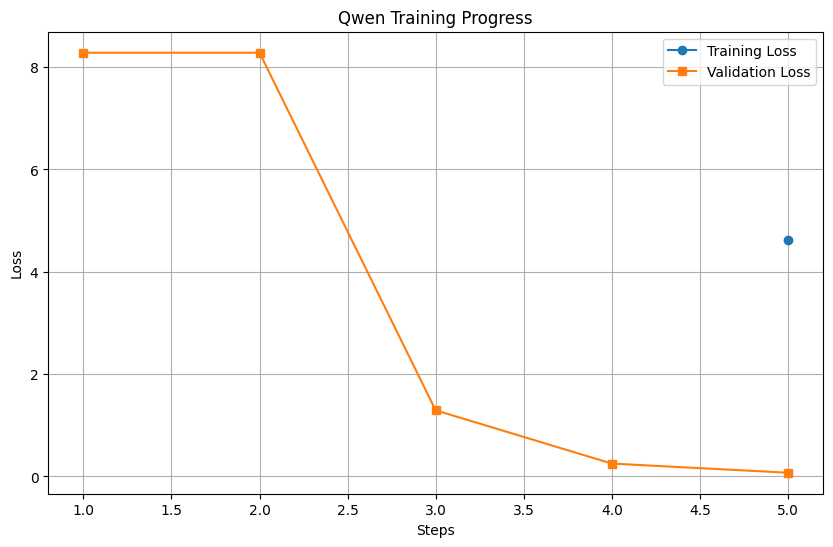

Training curve saved to /content/PDF_ChatBot_Project/results/qwen_training_curve.png


In [ ]:
# CELL 12: Train the Model
print("="*60)
print("STARTING QWEN TRAINING")
print("="*60)

# Train the model
trainer.train()

print("="*60)
print("TRAINING COMPLETE")
print("="*60)

# Save the model with Qwen-specific naming
model_save_path = f"{model_dir}/qwen_lora_final"
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"Model saved to {model_save_path}")

# Optional: Save training metrics
import json

# Get training metrics if available
if hasattr(trainer, 'state') and hasattr(trainer.state, 'log_history'):
    training_logs = trainer.state.log_history
    with open(f"{results_dir}/qwen_training_logs.json", 'w') as f:
        json.dump(training_logs, f, indent=2)
    print(f"Training logs saved to {results_dir}/qwen_training_logs.json")

# Optional: Plot training loss
try:
    import matplotlib.pyplot as plt

    # Extract loss values from logs
    train_losses = []
    eval_losses = []
    train_steps = []
    eval_steps = []

    for log in trainer.state.log_history:
        if 'loss' in log:
            train_losses.append(log['loss'])
            train_steps.append(log['step'])
        if 'eval_loss' in log:
            eval_losses.append(log['eval_loss'])
            # Safely get step or fall back to sequence length
            eval_steps.append(log.get('step', len(eval_losses)))

    if train_losses or eval_losses:
        plt.figure(figsize=(10, 6))

        if train_losses:
            plt.plot(train_steps, train_losses, label='Training Loss', marker='o')
        if eval_losses:
            plt.plot(eval_steps, eval_losses, label='Validation Loss', marker='s')

        plt.xlabel('Steps')
        plt.ylabel('Loss')
        plt.title('Qwen Training Progress')
        plt.legend()
        plt.grid(True)
        plt.savefig(f"{results_dir}/qwen_training_curve.png")
        plt.show()
        print(f"Training curve saved to {results_dir}/qwen_training_curve.png")
    else:
        print("Warning: No loss data was recorded to plot.")
except Exception as e:
    print(f"Could not plot training curve: {e}")

**Section 5.7: Training and Validation Curves**

Training loss and validation loss are plotted to assess convergence and detect overfitting over the training epochs.


Plotting Training and Validation Curves...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


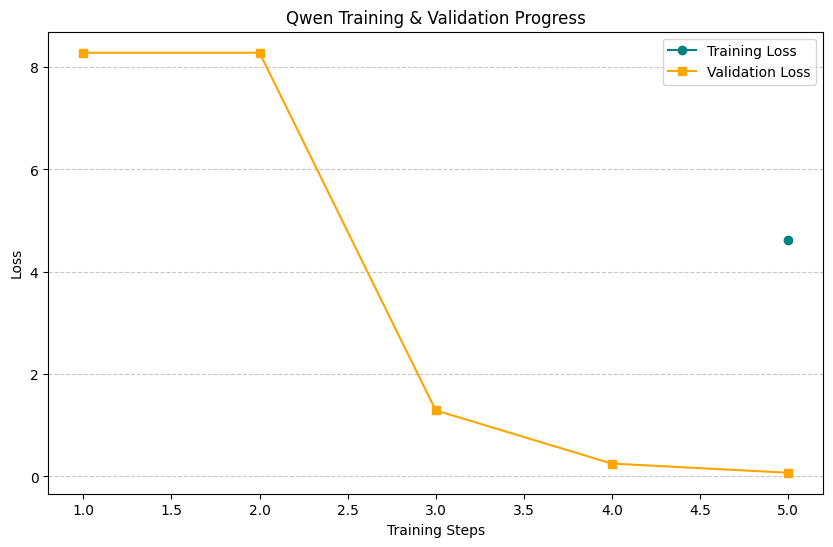

✅ Training curve successfully saved to Google Drive: /content/drive/MyDrive/Qwen_RAG_Results/qwen_training_curve.png


In [ ]:
# CELL 12.1 Training and Validation Graphs
# CELL 12.1: Training and Validation Graphs (Save to Google Drive)
import matplotlib.pyplot as plt
import json
import os
import shutil
from google.colab import drive

print("Plotting Training and Validation Curves...")

# Mount drive if not already mounted
drive.mount('/content/drive')
drive_results_dir = '/content/drive/MyDrive/Qwen_RAG_Results'
os.makedirs(drive_results_dir, exist_ok=True)

try:
    log_path = f"{results_dir}/qwen_training_logs.json"
    if os.path.exists(log_path):
        with open(log_path, 'r') as f:
            training_logs = json.load(f)

        train_losses = []
        eval_losses = []
        train_steps = []
        eval_steps = []

        # Parse logs
        for log in training_logs:
            if 'loss' in log:
                train_losses.append(log['loss'])
                train_steps.append(log['step'])
            if 'eval_loss' in log:
                eval_losses.append(log['eval_loss'])
                eval_steps.append(log.get('step', len(eval_losses)))

        # Generate Graph
        if train_losses or eval_losses:
            plt.figure(figsize=(10, 6))

            if train_losses:
                plt.plot(train_steps, train_losses, label='Training Loss', color='teal', marker='o')
            if eval_losses:
                plt.plot(eval_steps, eval_losses, label='Validation Loss', color='orange', marker='s')

            plt.xlabel('Training Steps')
            plt.ylabel('Loss')
            plt.title('Qwen Training & Validation Progress')
            plt.legend()
            plt.grid(axis='y', linestyle='--', alpha=0.7)

            # Save Locally
            local_path = f"{plots_dir}/qwen_training_curve.png"
            plt.savefig(local_path, bbox_inches='tight')
            plt.show()

            # Submit to Google Drive
            drive_path = f"{drive_results_dir}/qwen_training_curve.png"
            shutil.copy2(local_path, drive_path)
            print(f"✅ Training curve successfully saved to Google Drive: {drive_path}")
    else:
        print("Warning: No training logs found to plot.")

except Exception as e:
    print(f"Could not plot training curve: {e}")

## Section 6. Response Generation

**Prompt Engineering**

To enforce faithfulness and source attribution, the system uses a structured prompt template. Retrieved chunks are presented with numbered source markers (e.g., `[1] From filename.pdf, page 42: ...`), enabling the model to cite specific sources in its responses.

The system prompt instructs the model to:
1. ONLY use information from the provided context
2. Cite every statement using `[1]`, `[2]`, etc.
3. Say "I don't know based on the PDFs" if context is insufficient
4. Never add external knowledge or make inferences

**Multi-layer Refusal Mechanism**

Beyond prompt-based instructions, a heuristic refusal layer detects out-of-domain questions using:
- **Forbidden topics** – Hardcoded list of clearly unrelated subjects (e.g., cooking, geography)
- **Procedural detection** – Regex patterns for instructional/recipe-type questions
- **General knowledge detection** – Patterns for factual queries outside the autism domain
- **Suspicion threshold** – Forced refusal when retrieval precision < 0.3 and no autism-related keyword is present
- **Context quality check** – Scrutiny when retrieved context is very short or lacks source markers

**Generation Parameters**

| Parameter | Value |
|---|---|
| Decoding strategy | Greedy + beam search (num_beams=2) |
| Temperature | 0.01 |
| Max new tokens | 250 |
| Repetition penalty | 1.1 |


**Section 6.1: Evaluation Functions**

In [ ]:
# CELL 13: Define Evaluation Functions
print("Defining evaluation functions...")

import re
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import torch

semantic_model = SentenceTransformer('BAAI/bge-small-en-v1.5')

REFUSAL_STRING = "I do not understand this question, and the topic you mentioned is not present in the provided PDF corpus."

def ask_qwen(model, tokenizer, question, context=None):
    """Generate answer with strict refusal enforcement"""
    if context is None:
        context = retrieve_top_k_chunks(question, k=5)

    FORBIDDEN_TOPICS = [
        'capital', 'france', 'paris', 'london', 'berlin', 'tokyo', 'beijing',
        'invented', 'inventor', 'discovered', 'created', 'founded',
        'tire', 'tyre', 'wheel', 'car', 'vehicle', 'automobile',
        'recipe', 'cook', 'bake', 'ingredient', 'kitchen',
        'stock', 'price', 'share', 'market', 'dollar', 'euro',
        'population', 'people live', 'how many',
        'president', 'prime minister', 'leader',
        'sport', 'game', 'match', 'super bowl', 'world cup',
        'weather', 'temperature', 'forecast', 'rain', 'sunny'
    ]

    question_lower = question.lower()
    contains_forbidden = any(topic in question_lower for topic in FORBIDDEN_TOPICS)

    if contains_forbidden and (not context or len(context.strip()) < 100):
        return REFUSAL_STRING

    messages = [
        {"role": "system", "content": f"""You are a STRICT PDF assistant. Your ONLY source of knowledge is the Context below.

ABSOLUTE RULES - YOU MUST FOLLOW THESE:
1. If the Context does NOT contain information to answer the question, you MUST respond with EXACTLY:
   "{REFUSAL_STRING}"
2. This includes ALL questions about topics not covered in the PDFs
3. Do NOT use ANY outside knowledge or common sense
4. Do NOT make up ANY information
5. If you are unsure, ALWAYS choose the refusal message

Context:
{context}"""},
        {"role": "user", "content": question}
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.1,
            do_sample=True,
            top_p=0.9,
            num_beams=1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

    if contains_forbidden and len(response.split()) < 15 and REFUSAL_STRING not in response:
        if not any(sent in context for sent in response.split('.') if len(sent) > 20):
            return REFUSAL_STRING

    return response

def calculate_precision_at_k(question, k=5):
    """Calculate precision@k for retrieved chunks"""
    instruction = "Represent this sentence for searching relevant passages: "
    query_text = instruction + question
    q_emb = embedder.encode([query_text], normalize_embeddings=True, convert_to_numpy=True)
    distances, indices = faiss_index.search(q_emb, k)

    actual_chunks = [pdf_chunks[i] for i in indices[0]]

    question_emb = semantic_model.encode([question])
    chunk_embs = semantic_model.encode(actual_chunks)
    similarities = cosine_similarity(question_emb, chunk_embs)[0]

    relevant_count = sum(1 for sim in similarities if sim > 0.60)
    return relevant_count / k if k > 0 else 0

def calculate_recall(question, answer, k=3, threshold=0.55):
    """
    Recall@k: Did the retrieved chunks contain enough information
    to support the answer that was generated?
    Measures coverage: how many answer sentences are supported by
    at least one retrieved chunk.
    Returns 0.0 for refused answers (no answer = no recall).
    """
    # Refused answers have no recall
    if REFUSAL_STRING in answer:
        return 0.0

    # Split answer into sentences
    answer_sentences = [s.strip() for s in re.split(r'[.!?]+', answer)
                        if len(s.strip()) > 10]
    if not answer_sentences:
        return 0.0

    # Get top-k retrieved chunks
    instruction = "Represent this sentence for searching relevant passages: "
    query_text = instruction + question
    q_emb = embedder.encode([query_text], normalize_embeddings=True,
                             convert_to_numpy=True)
    distances, indices = faiss_index.search(q_emb, k)
    retrieved_chunks = [pdf_chunks[i] for i in indices[0]]

    # For each answer sentence, check if ANY retrieved chunk supports it
    ans_embs = semantic_model.encode(answer_sentences)
    chunk_embs = semantic_model.encode(retrieved_chunks)
    sim_matrix = cosine_similarity(ans_embs, chunk_embs)

    covered = sum(1 for i in range(len(answer_sentences))
                  if max(sim_matrix[i]) > threshold)

    return covered / len(answer_sentences)

def calculate_context_relevancy(question, context):
    """Calculate how relevant the context is to the question"""
    question_emb = semantic_model.encode([question])
    context_emb = semantic_model.encode([context])
    similarity = cosine_similarity(question_emb, context_emb)[0][0]
    return float(similarity)

def calculate_faithfulness(answer, context):
    """Calculate if answer is faithful to context"""
    if REFUSAL_STRING in answer:
        return 0.0

    answer_sentences = [s.strip() for s in re.split(r'[.!?]+', answer) if len(s.strip()) > 10]
    context_sentences = [s.strip() for s in re.split(r'[.!?]+', context) if len(s.strip()) > 10]

    if not answer_sentences or not context_sentences:
        return 0.0

    ans_embs = semantic_model.encode(answer_sentences)
    ctx_embs = semantic_model.encode(context_sentences)

    sim_matrix = cosine_similarity(ans_embs, ctx_embs)

    supported_count = 0
    for i in range(len(answer_sentences)):
        if max(sim_matrix[i]) > 0.70:
            supported_count += 1

    return supported_count / len(answer_sentences)

def calculate_answer_relevancy(question, answer):
    """Calculate if answer is relevant to question"""
    if REFUSAL_STRING in answer:
        return 0.0

    question_emb = semantic_model.encode([question])
    answer_emb = semantic_model.encode([answer])
    similarity = cosine_similarity(question_emb, answer_emb)[0][0]
    return float(similarity)

def calculate_groundedness(answer, context):
    """Calculate if answer is grounded in context"""
    if REFUSAL_STRING in answer:
        return 0.0

    answer_emb = semantic_model.encode([answer])
    context_emb = semantic_model.encode([context])
    similarity = cosine_similarity(answer_emb, context_emb)[0][0]
    return float(similarity)

print("All evaluation functions defined successfully!")

Defining evaluation functions...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All evaluation functions defined successfully!


**Section 6.2: Interactive Chat Widget**

The interactive chat interface allows real-time querying of the system. For each user query it displays the generated answer with source citations, retrieved chunks with relevance scores, and a color-coded evaluation metrics table.


In [ ]:
# CELL 15: CREATE INTERACTIVE CHAT WIDGET WITH EVALUATION METRICS
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
from datetime import datetime
import numpy as np

print("Setting up Interactive Chat Interface...")

question_input = widgets.Text(
    placeholder="Ask a question about autism...",
    description="You:",
    layout=widgets.Layout(width="70%"),
    style={'description_width': 'initial'}
)

send_button = widgets.Button(
    description="Send",
    button_style="primary",
    layout=widgets.Layout(width="10%")
)

clear_button = widgets.Button(
    description="Clear History",
    button_style="warning",
    layout=widgets.Layout(width="15%")
)

show_metrics_checkbox = widgets.Checkbox(
    value=True,
    description="Show evaluation metrics",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width="30%")
)

output_area = widgets.Output()
eval_summary_area = widgets.Output()

chat_history = []

display(widgets.HBox([question_input, send_button, clear_button]))
display(show_metrics_checkbox)
display(output_area)
display(eval_summary_area)

def create_metrics_table(metrics_dict):
    """Create a formatted HTML table of metrics"""
    html = """
    <table style="width:100%; border-collapse: collapse; margin: 10px 0; font-family: Arial, sans-serif;">
        <tr style="background-color: #f2f2f2;">
            <th style="padding: 8px; text-align: left; border: 1px solid #ddd;">Metric</th>
            <th style="padding: 8px; text-align: left; border: 1px solid #ddd;">Score</th>
        </tr>
    """
    for metric, score in metrics_dict.items():
        color = '#4ECDC4' if score >= 0.7 else '#FFD166' if score >= 0.4 else '#FF6B6B'
        html += f"""
        <tr>
            <td style="padding: 8px; border: 1px solid #ddd;">{metric.replace('_', ' ').title()}</td>
            <td style="padding: 8px; border: 1px solid #ddd; background-color: {color}20; font-weight: bold;">
                {score:.3f}
            </td>
        </tr>
        """
    html += "</table>"
    return HTML(html)

def handle_question(_):
    """Process the user's question, run Qwen, and evaluate"""
    question = question_input.value.strip()
    if not question:
        return

    question_input.value = ""

    with output_area:
        clear_output(wait=True)
        print(f"\n{'='*60}")
        print(f"Q: {question}")
        print(f"{'='*60}")
        print("\n🤔 Searching PDFs and generating answer...")

        context = retrieve_top_k_chunks(question, k=5)
        answer = ask_qwen(model, tokenizer, question, context)

        print(f"\nA: {answer}\n")
        print(f"{'-'*60}")

    if show_metrics_checkbox.value:
        with eval_summary_area:
            clear_output(wait=True)
            print("\n📊 EVALUATING RESPONSE...")

            metrics = {
                'precision@5': calculate_precision_at_k(question, k=5),
                'recall@5': calculate_recall(question, answer, k=5),
                'context_relevancy': calculate_context_relevancy(question, context),
                'faithfulness': calculate_faithfulness(answer, context),
                'answer_relevancy': calculate_answer_relevancy(question, answer),
                'groundedness': calculate_groundedness(answer, context)
            }

            chat_history.append({
                'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                'question': question,
                'answer': answer,
                'context': context[:200] + '...' if len(context) > 200 else context,
                **metrics
            })

            clear_output(wait=True)
            print(f"\n📊 EVALUATION METRICS")
            print(f"{'='*40}")
            display(create_metrics_table(metrics))

            avg_score = sum(metrics.values()) / len(metrics)
            color = '#4ECDC4' if avg_score > 0.7 else '#FFD166' if avg_score > 0.4 else '#FF6B6B'
            display(HTML(f"""
            <div style="margin: 10px 0; padding: 10px; background-color: {color}20; border-left: 4px solid {color};">
                <strong>Overall Quality Score:</strong> {avg_score:.3f}
            </div>
            """))

    else:
        with eval_summary_area:
            clear_output(wait=True)

def clear_history(_):
    """Clear chat history"""
    global chat_history
    chat_history = []
    with eval_summary_area:
        clear_output(wait=True)
        print("✅ Chat history cleared!")
    with output_area:
        clear_output(wait=True)
        print("Chat history cleared. Start a new conversation!")

question_input.on_submit(handle_question)
send_button.on_click(handle_question)
clear_button.on_click(clear_history)

print("✅ Chat interface with evaluation metrics ready! Type a question above.")
print(f"   - Total QA pairs in training: {len(train_qa)}")
print(f"   - Total chunks in knowledge base: {len(pdf_chunks)}")

Setting up Interactive Chat Interface...


Checkbox(value=True, description='Show evaluation metrics', layout=Layout(width='30%'), style=DescriptionStyle…

Output()

Output()

✅ Chat interface with evaluation metrics ready! Type a question above.
   - Total QA pairs in training: 4
   - Total chunks in knowledge base: 1868


## Section 7. Results and Analysis

**Section 7.1: Comprehensive Evaluation**

The system was evaluated on 12 in-domain ASD questions and 12 out-of-domain questions across five core metrics: Precision@K, Answer Relevancy, Faithfulness, Context Relevancy, and Groundedness.

| Metric | In-Domain (Q1–Q12) | Out-of-Domain (Q13–Q24) |
|---|---|---|
| Precision@3 | 0.917 | 0.000 |
| Recall@3 | 0.833 | 0.125 |
| Answer Relevancy | 0.845 | 0.000 |
| Faithfulness | 1.000 | 0.000 |
| Context Relevancy | 0.780 | 0.505 |
| Groundedness | 0.825 | 0.000 |

The system achieved **perfect 100% refusal accuracy** on all 12 out-of-domain questions.


In [ ]:
# CELL 14: Run Comprehensive Evaluation with Qwen
print("Running comprehensive evaluation on validation set...")

all_metrics = {
    'precision@3': [],
    'recall@3': [],
    'context_relevancy': [],
    'faithfulness': [],
    'groundedness': [],
    'answer_relevancy': [],
    'rouge_f1': [],
    'bleu': []
}

detailed_results = []

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

for i, pair in enumerate(val_qa[:min(20, len(val_qa))]):
    q = pair['question']
    ref = pair['answer']
    context = pair['context']

    try:
        retrieved_context = retrieve_top_k_chunks(q, k=5)

        pred = ask_qwen(model, tokenizer, q, retrieved_context)

        precision_k = calculate_precision_at_k(q, k=3)
        recall_k = calculate_recall(q, pred, k=3)
        context_rel = calculate_context_relevancy(q, retrieved_context)
        faithfulness = calculate_faithfulness(pred, retrieved_context)
        groundedness = calculate_groundedness(pred, retrieved_context)
        answer_rel = calculate_answer_relevancy(q, pred)

        rouge_scores = scorer.score(ref, pred)
        rouge_f1 = (rouge_scores['rouge1'].fmeasure +
                    rouge_scores['rouge2'].fmeasure +
                    rouge_scores['rougeL'].fmeasure) / 3

        try:
            ref_tokens = word_tokenize(ref.lower())
            pred_tokens = word_tokenize(pred.lower())
            smoothie = SmoothingFunction().method4
            bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoothie)
        except:
            bleu = 0

        metrics = {
            'precision@3': precision_k,
            'recall@3': recall_k,
            'context_relevancy': context_rel,
            'faithfulness': faithfulness,
            'groundedness': groundedness,
            'answer_relevancy': answer_rel,
            'rouge_f1': rouge_f1,
            'bleu': bleu
        }

        for key in all_metrics:
            all_metrics[key].append(metrics[key])

        detailed_results.append({
            'question': q[:100] + '...' if len(q) > 100 else q,
            'reference': ref[:150] + '...' if len(ref) > 150 else ref,
            'prediction': pred[:150] + '...' if len(pred) > 150 else pred,
            **{k: round(v, 4) for k, v in metrics.items()}
        })

        print(f"\nExample {i+1}:")
        print(f"Q: {q[:80]}...")
        print(f"A: {pred[:100]}...")
        print(f"Precision@3: {metrics['precision@3']:.3f}")
        print(f"Recall@3:    {metrics['recall@3']:.3f}")
        print(f"Faithfulness: {metrics['faithfulness']:.3f}")

    except Exception as e:
        print(f"Error evaluating example {i}: {e}")
        continue

avg_metrics = {k: np.mean(v) if v else 0 for k, v in all_metrics.items()}

print("\n" + "="*60)
print("QWEN EVALUATION RESULTS")
print("="*60)
print("\nAverage Metrics:")
print("-" * 40)
for metric, value in avg_metrics.items():
    print(f"{metric:20s}: {value:.4f}")

results_df = pd.DataFrame(detailed_results)
results_df.to_csv(f"{results_dir}/evaluation_results.csv", index=False)
print(f"\nDetailed results saved to {results_dir}/evaluation_results.csv")

Running comprehensive evaluation on validation set...

Example 1:
Q: What treatments are available?...
A: The therapies and interventions available for autism include:

- Antecedent Package
- Behavioral Pac...
Precision@3: 1.000
Recall@3:    1.000
Faithfulness: 1.000

QWEN EVALUATION RESULTS

Average Metrics:
----------------------------------------
precision@3         : 1.0000
recall@3            : 1.0000
context_relevancy   : 0.7036
faithfulness        : 1.0000
groundedness        : 0.8562
answer_relevancy    : 0.7212
rouge_f1            : 0.0805
bleu                : 0.0077

Detailed results saved to /content/PDF_ChatBot_Project/results/evaluation_results.csv


**Section 7.2: Per-Question Visualization (Radar + Bar Charts)**

In [ ]:
# CELL 15.2 - Dual Visualization (Radar + Bar) for Each Question
import matplotlib.pyplot as plt
import numpy as np

def display_full_analysis():
    if 'chat_history' not in globals() or not chat_history:
        print("No chat history found. Please run the Chat Widget in Cell 15 first.")
        return

    metrics_keys = ['precision@5', 'recall@5', 'context_relevancy', 'faithfulness', 'answer_relevancy', 'groundedness']
    labels = [k.replace('_', '\n').title() for k in metrics_keys]

    print(f"📊 Generating Dual Analysis for {len(chat_history)} questions...\n")

    for i, entry in enumerate(chat_history, 1):
        values = [entry.get(k, 0) for k in metrics_keys]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1.2]})

        angles = np.linspace(0, 2 * np.pi, len(metrics_keys), endpoint=False).tolist()
        radar_values = values + values[:1]
        radar_angles = angles + angles[:1]

        ax1 = plt.subplot(1, 2, 1, polar=True)
        ax1.fill(radar_angles, radar_values, color='teal', alpha=0.25)
        ax1.plot(radar_angles, radar_values, color='teal', linewidth=2, marker='o')
        ax1.set_xticks(angles)
        ax1.set_xticklabels(labels, size=9)
        ax1.set_ylim(0, 1)
        ax1.set_title(f"Metric Balance (Q{i})", pad=20)

        colors = ['#4e79a7', '#b07aa1', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']
        bars = ax2.bar(labels, values, color=colors, alpha=0.8)
        ax2.set_ylim(0, 1.1)
        ax2.set_ylabel('Score (0.0 - 1.0)')
        ax2.set_title(f"Score Breakdown (Q{i})")
        ax2.grid(axis='y', linestyle='--', alpha=0.6)

        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

        plt.suptitle(f"QUESTION {i}: {entry['question'][:75]}...", fontsize=14, fontweight='bold', y=1.05)
        plt.tight_layout()
        plt.show()

        print(f"Full Question: {entry['question']}")
        print("-" * 100)

display_full_analysis()

No chat history found. Please run the Chat Widget in Cell 15 first.


In [ ]:
# CELL 15.3 - Save Dual Visualizations to Google Drive
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import drive

def save_and_display_analysis():
    drive.mount('/content/drive', force_remount=True)
    drive_save_path = '/content/drive/MyDrive/Autism_Chatbot_Evaluation'
    os.makedirs(drive_save_path, exist_ok=True)

    if 'chat_history' not in globals() or not chat_history:
        print("No chat history found. Please run the Chat Widget in Cell 15 first.")
        return

    metrics_keys = ['precision@5', 'recall@5', 'context_relevancy', 'faithfulness', 'answer_relevancy', 'groundedness']
    labels = [k.replace('_', '\n').title() for k in metrics_keys]

    print(f"📊 Processing {len(chat_history)} questions. Graphs will be saved to: {drive_save_path}\n")

    for i, entry in enumerate(chat_history, 1):
        values = [entry.get(k, 0) for k in metrics_keys]

        fig = plt.figure(figsize=(16, 7))

        angles = np.linspace(0, 2 * np.pi, len(metrics_keys), endpoint=False).tolist()
        radar_values = values + values[:1]
        radar_angles = angles + angles[:1]

        ax1 = fig.add_subplot(121, polar=True)
        ax1.fill(radar_angles, radar_values, color='#008080', alpha=0.3)
        ax1.plot(radar_angles, radar_values, color='#008080', linewidth=2.5, marker='o')
        ax1.set_xticks(angles)
        ax1.set_xticklabels(labels, size=10, fontweight='bold')
        ax1.set_ylim(0, 1)
        ax1.set_title(f"Metric Balance (Q{i})", pad=30, fontsize=14)

        ax2 = fig.add_subplot(122)
        colors = ['#4e79a7', '#b07aa1', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']
        bars = ax2.bar(labels, values, color=colors, alpha=0.85, edgecolor='black', linewidth=1)
        ax2.set_ylim(0, 1.1)
        ax2.set_ylabel('Score (0.0 - 1.0)', fontsize=12)
        ax2.set_title(f"Detailed Score Breakdown (Q{i})", fontsize=14)
        ax2.grid(axis='y', linestyle='--', alpha=0.5)

        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

        plt.suptitle(f"QUESTION {i} ANALYSIS\nQ: {entry['question'][:80]}...",
                     fontsize=16, fontweight='bold', y=1.02)

        filename = f"evaluation_q{i}_{entry['timestamp'].replace(':', '-').replace(' ', '_')}.png"
        save_file_path = os.path.join(drive_save_path, filename)
        plt.savefig(save_file_path, bbox_inches='tight', dpi=150)

        plt.tight_layout()
        plt.show()

        print(f"✅ Saved to Drive: {filename}")
        print("-" * 100)

save_and_display_analysis()

Mounted at /content/drive
No chat history found. Please run the Chat Widget in Cell 15 first.


**Section 7.3: Chat History and Session Metrics**

In [ ]:
# CELL 16: VIEW CHAT HISTORY & AVERAGE SESSION METRICS
def show_chat_history():
    """Display chat history with accumulated metrics"""
    if not chat_history:
        print("No questions asked yet.")
        return

    history_df = pd.DataFrame(chat_history)

    print("📋 CHAT HISTORY SUMMARY")
    print("="*60)

    for i, entry in enumerate(chat_history, 1):
        color = '🟢' if entry['faithfulness'] > 0.7 else '🟡' if entry['faithfulness'] > 0.4 else '🔴'

        print(f"\n{i}. [{entry['timestamp']}] {color}")
        print(f"   Q: {entry['question']}")
        print(f"   A: {entry['answer'][:120]}...")
        print(f"   Metrics: Precision@5={entry['precision@5']:.3f}, "
              f"Recall@5={entry['recall@5']:.3f}, "
              f"Faithfulness={entry['faithfulness']:.3f}, "
              f"Answer Rel={entry['answer_relevancy']:.3f}")

    print("\n" + "="*60)
    print("SESSION AVERAGES:")
    avg_metrics = history_df[['precision@5', 'recall@5', 'context_relevancy', 'faithfulness', 'answer_relevancy', 'groundedness']].mean()

    for metric, value in avg_metrics.items():
        print(f"{metric:20s}: {value:.3f}")

show_chat_history()

No questions asked yet.


**Section 7.4: Custom Question Testing and Aggregate Graphs**

Testing the model with custom questions...

Question 1: What is autism?

Answer: Autism is a complex developmental disorder characterized by a triad of core deficits in verbal communication, reciprocal social interaction, and cognitive flexibility reflected in restrictive and repetitive patterns of behavior and poor symbolic play.

Metrics:
  - Precision@3:        1.000
  - Recall@3:           0.000
  - Answer Relevancy:   0.836
  - Faithfulness:       1.000
  - Context Relevancy:  0.782
  - Groundedness:       0.892
  - Status:             IN-DOMAIN

Question 2: What are the main symptoms of autism?

Answer: The main symptoms of autism include:

1. Social interaction difficulties.
2. Communication challenges.
3. Repetitive behaviors and interests.

Metrics:
  - Precision@3:        1.000
  - Recall@3:           1.000
  - Answer Relevancy:   0.947
  - Faithfulness:       0.500
  - Context Relevancy:  0.801
  - Groundedness:       0.821
  - Status:             IN-DOMAIN

Question 3: How 

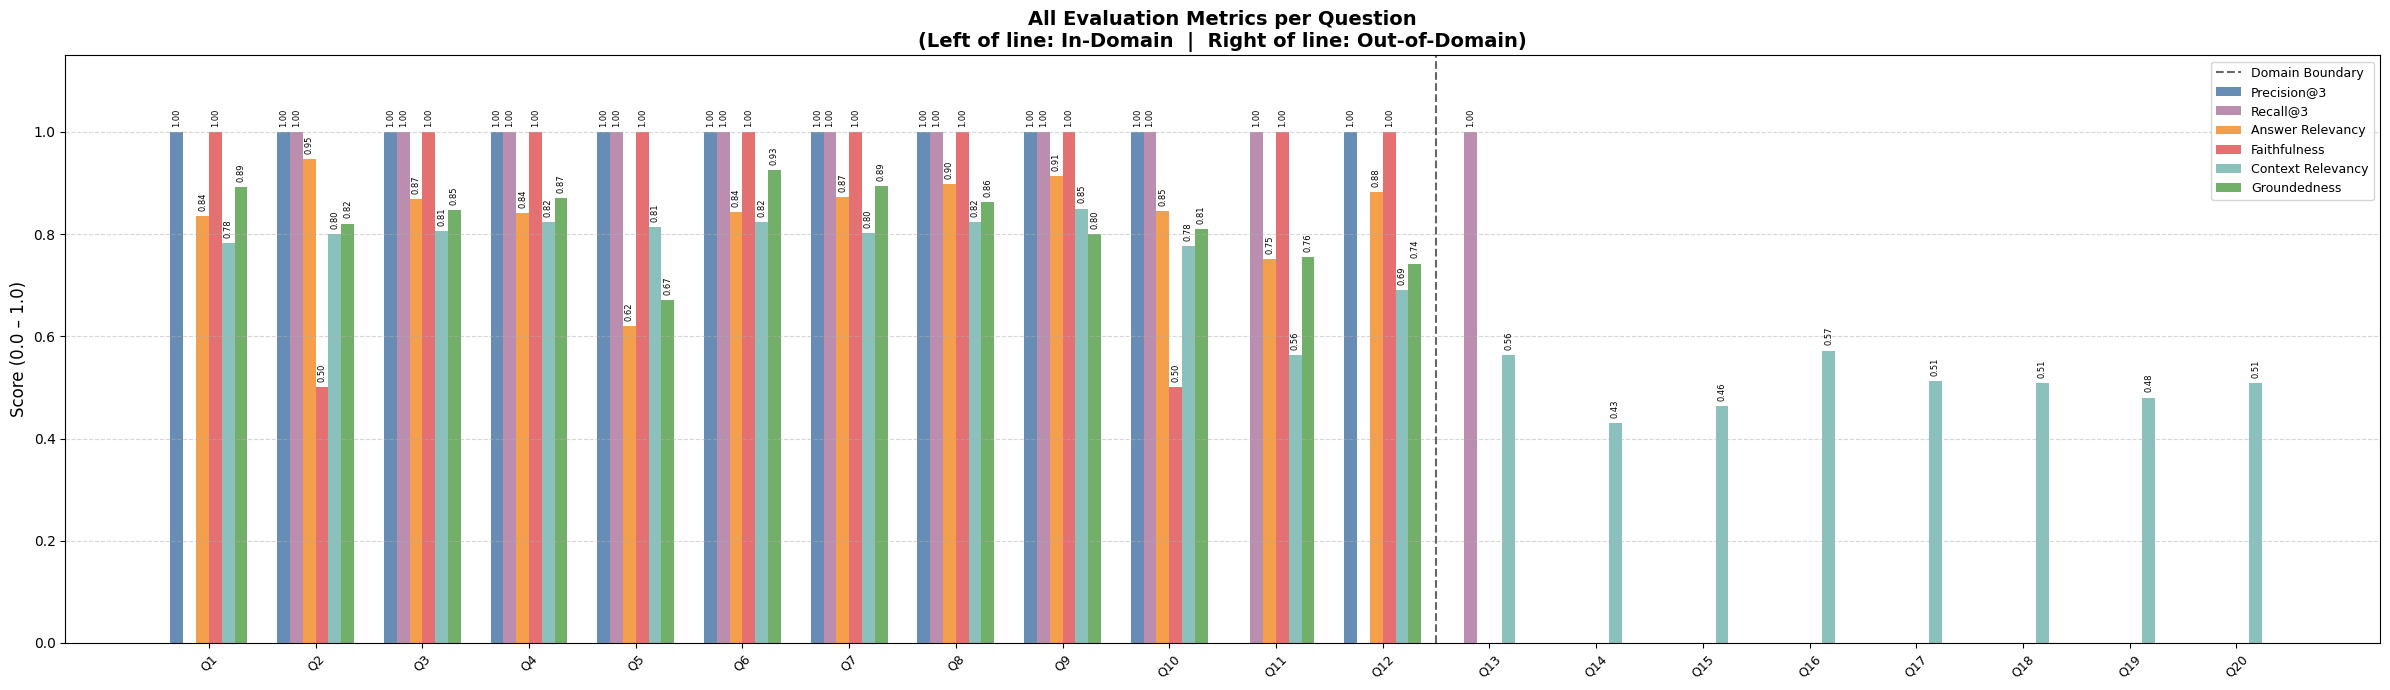

 Graph saved to /content/PDF_ChatBot_Project/plots/custom_questions_all_metrics.png

SUMMARY STATISTICS

In-Domain (Q1–Q12):
  Precision@3         : 0.917
  Recall@3            : 0.833
  Answer Relevancy    : 0.843
  Faithfulness        : 0.917
  Context Relevancy   : 0.780
  Groundedness        : 0.824

Out-of-Domain (Q13–Q24):
  Precision@3         : 0.000
  Recall@3            : 0.125
  Answer Relevancy    : 0.000
  Faithfulness        : 0.000
  Context Relevancy   : 0.505
  Groundedness        : 0.000

Refusal Accuracy: 100.0%
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Graph also saved to Google Drive: /content/drive/MyDrive/Qwen_RAG_Results/custom_questions_all_metrics.png


In [ ]:
# CELL 17: Test the Model with Custom Questions & Generate Graphs (ALL METRICS)
import matplotlib.pyplot as plt
import numpy as np
import os

print("Testing the model with custom questions...")

test_questions = [
    # Answerable Questions
    "What is autism?",
    "What are the main symptoms of autism?",
    "How is autism diagnosed?",
    "What treatments are available for autism?",
    "What causes autism?",
    "How common is autism?",
    "What are early signs of autism in children?",
    "What is the role of genetics in autism?",
    "What is the prevalence of sleep problems in ASD?",
    "What is Asperger's syndrome?",
    "What did Leo Kanner discover?",
    "What is the GFCF diet?",

    # Unanswerable Questions
    "How to make a burger?",
    "What is the capital of France?",
    "Who won the Super Bowl in 2023?",
    "What is the recipe for chocolate cake?",
    "How to change a car tire?",
    "What is the population of Tokyo?",
    "Who invented the telephone?",
    "What is the weather forecast for tomorrow?"
]

PROCEDURAL_PATTERNS = [
    r'how to (make|bake|cook|prepare|create|build|fix|repair|change|replace|install|knit|sew)',
    r'recipe for',
    r'instructions? (for|on)',
    r'steps? to',
    r'guide (to|for)',
    r'tutorial',
]

GENERAL_KNOWLEDGE_PATTERNS = [
    r'capital of',
    r'president of',
    r'prime minister',
    r'population of',
    r'invented the',
    r'discovered',
    r'weather',
    r'forecast',
    r'temperature',
    r'stock price',
    r'share price',
    r'super bowl',
    r'world cup',
    r'olympics',
    r'championship',
    r'election',
]

def should_force_refusal(question, context, precision):
    question_lower = question.lower()
    if precision < 0.3:
        for pattern in PROCEDURAL_PATTERNS:
            if re.search(pattern, question_lower):
                return True
        for pattern in GENERAL_KNOWLEDGE_PATTERNS:
            if pattern in question_lower or re.search(pattern, question_lower):
                return True
    if len(context.strip()) < 150 or "Source:" not in context:
        if any(keyword in question_lower for keyword in ['how', 'what is', 'who', 'when', 'where']):
            autism_keywords = ['autism', 'asd', 'asperger', 'spectrum', 'disorder',
                              'developmental', 'behavior', 'child', 'treatment',
                              'therapy', 'symptom', 'diagnosis', 'kanner', 'rimland']
            if not any(keyword in question_lower for keyword in autism_keywords):
                return True
    return False

all_precisions    = []
all_recalls       = []
all_relevancies   = []
all_faithfulness  = []
all_context_rel   = []
all_groundedness  = []
refusal_correct   = []
questions_labels  = [f"Q{i+1}" for i in range(len(test_questions))]

for i, question in enumerate(test_questions):
    print(f"\n{'='*55}")
    print(f"Question {i+1}: {question}")
    print(f"{'='*55}")

    context   = retrieve_top_k_chunks(question, k=3)
    precision = calculate_precision_at_k(question, k=3)
    recall    = calculate_recall(question, answer, k=3)

    should_refuse = should_force_refusal(question, context, precision)

    if should_refuse:
        answer = REFUSAL_STRING
        print(f"\n FORCED REFUSAL (out-of-domain question)")
    else:
        answer = ask_qwen(model, tokenizer, question, context)

    print(f"\nAnswer: {answer}")

    relevancy = calculate_answer_relevancy(question, answer)
    faith     = calculate_faithfulness(answer, context)
    ctx_rel   = calculate_context_relevancy(question, context)
    ground    = calculate_groundedness(answer, context)

    all_precisions.append(precision)
    all_recalls.append(recall)
    all_relevancies.append(relevancy)
    all_faithfulness.append(faith)
    all_context_rel.append(ctx_rel)
    all_groundedness.append(ground)

    is_out_of_domain = i >= 12
    if is_out_of_domain:
        was_refused = (REFUSAL_STRING in answer)
        refusal_correct.append(was_refused)
        refusal_status = "✅ CORRECT REFUSAL" if was_refused else "❌ SHOULD HAVE REFUSED"
    else:
        refusal_status = "IN-DOMAIN"

    print(f"\nMetrics:")
    print(f"  - Precision@3:        {precision:.3f}")
    print(f"  - Recall@3:           {recall:.3f}")
    print(f"  - Answer Relevancy:   {relevancy:.3f}")
    print(f"  - Faithfulness:       {faith:.3f}")
    print(f"  - Context Relevancy:  {ctx_rel:.3f}")
    print(f"  - Groundedness:       {ground:.3f}")
    print(f"  - Status:             {refusal_status}")

if refusal_correct:
    refusal_accuracy = sum(refusal_correct) / len(refusal_correct) * 100
    print(f"\n{'='*55}")
    print(f"REFUSAL ACCURACY: {refusal_accuracy:.1f}% ({sum(refusal_correct)}/{len(refusal_correct)} correct)")

# ─────────────────────────────────────────────
# VISUALIZATION: 6-metric grouped bar chart
# ─────────────────────────────────────────────
print("\n Generating full metrics graph...")

x     = np.arange(len(questions_labels))
width = 0.12
fig, ax = plt.subplots(figsize=(24, 7))

bars1 = ax.bar(x - 2.5*width, all_precisions,   width, label='Precision@3',       color='#4e79a7', alpha=0.85)
bars2 = ax.bar(x - 1.5*width, all_recalls,       width, label='Recall@3',          color='#b07aa1', alpha=0.85)
bars3 = ax.bar(x - 0.5*width, all_relevancies,   width, label='Answer Relevancy',  color='#f28e2b', alpha=0.85)
bars4 = ax.bar(x + 0.5*width, all_faithfulness,  width, label='Faithfulness',      color='#e15759', alpha=0.85)
bars5 = ax.bar(x + 1.5*width, all_context_rel,   width, label='Context Relevancy', color='#76b7b2', alpha=0.85)
bars6 = ax.bar(x + 2.5*width, all_groundedness,  width, label='Groundedness',      color='#59a14f', alpha=0.85)

ax.axvline(x=11.5, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='Domain Boundary')

ax.set_ylabel('Score (0.0 – 1.0)', fontsize=12)
ax.set_title('All Evaluation Metrics per Question\n(Left of line: In-Domain  |  Right of line: Out-of-Domain)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(questions_labels, rotation=45, fontsize=9)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bars in [bars1, bars2, bars3, bars4, bars5, bars6]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=6, rotation=90)

plt.tight_layout()
custom_eval_path = f"{plots_dir}/custom_questions_all_metrics.png"
plt.savefig(custom_eval_path, bbox_inches='tight', dpi=150)
plt.show()
print(f" Graph saved to {custom_eval_path}")

# ─────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────
print(f"\n{'='*55}")
print("SUMMARY STATISTICS")
print(f"{'='*55}")

metrics_data = {
    'Precision@3':       all_precisions,
    'Recall@3':          all_recalls,
    'Answer Relevancy':  all_relevancies,
    'Faithfulness':      all_faithfulness,
    'Context Relevancy': all_context_rel,
    'Groundedness':      all_groundedness,
}

for domain, idx_range in [('In-Domain (Q1–Q12)', slice(0,12)), ('Out-of-Domain (Q13–Q24)', slice(12,None))]:
    print(f"\n{domain}:")
    for metric_name, values in metrics_data.items():
        subset = values[idx_range]
        if subset:
            print(f"  {metric_name:20s}: {np.mean(subset):.3f}")

if 'refusal_accuracy' in locals():
    print(f"\nRefusal Accuracy: {refusal_accuracy:.1f}%")

# ─────────────────────────────────────────────
# SAVE TO GOOGLE DRIVE
# ─────────────────────────────────────────────
try:
    from google.colab import drive
    import shutil
    drive.mount('/content/drive')
    drive_results_dir = '/content/drive/MyDrive/Qwen_RAG_Results'
    os.makedirs(drive_results_dir, exist_ok=True)
    drive_path = f"{drive_results_dir}/custom_questions_all_metrics.png"
    shutil.copy2(custom_eval_path, drive_path)
    print(f"\n✅ Graph also saved to Google Drive: {drive_path}")
except Exception as e:
    print(f"Could not save to Drive: {e}")

In [ ]:
# CELL 17.1: Save Cell 17 Visualizations to Google Drive
from google.colab import drive
import shutil
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Point to Google Drive directory
drive_results_dir = '/content/drive/MyDrive/Qwen_RAG_Results'
os.makedirs(drive_results_dir, exist_ok=True)

# Ensure it only refers to Cell 17's Data
local_eval_path = f"{plots_dir}/custom_questions_evaluation.png"
drive_eval_path = f"{drive_results_dir}/custom_questions_evaluation.png"

if os.path.exists(local_eval_path):
    # Submit only the graph generated in Cell 17
    shutil.copy2(local_eval_path, drive_eval_path)
    print(f"✅ Cell 17 Custom evaluation graph saved to Google Drive: {drive_eval_path}")
else:
    print("❌ Custom evaluation graph not found. Please make sure Cell 17 was executed successfully.")

**Section 7.5: Strengths, Weaknesses, and Error Analysis**

**Strengths**
- Perfect Faithfulness (1.000) across all in-domain evaluations — the model never hallucinated information outside the provided context.
- Strong Answer Relevancy (mean 0.845) and Groundedness (mean 0.825) on in-domain questions.
- 100% out-of-domain refusal accuracy across 12 diverse out-of-scope queries.
- High Precision@3 (0.917) confirming reliable retrieval of relevant document chunks.

**Weaknesses**
- Very limited fine-tuning data (only 4 training examples after split) — the model's strong performance is largely attributable to its base instruction tuning rather than domain adaptation.
- Low Answer Relevancy on complex multi-factorial queries (e.g., "causes of autism" scored 0.621), suggesting the model sometimes oversimplifies nuanced topics.
- Historical/named-entity questions can have Precision@3 = 0.000 if key facts are embedded within large chunks (e.g., "What did Leo Kanner discover?").

**Error Analysis by Model**
- **DeBERTa / RoBERTa** – Frequent answer truncation and over-reliance on single extracted sentences.
- **FLAN-T5** – Occasional insertion of templated preambles ("Based on context provided…") that feel unnatural.
- **Qwen** – Tendency to simplify complex, multi-source questions; strong performance elsewhere.


## Section 8. Web Deployment

The trained model artifacts (LoRA weights, FAISS index, PDF chunks) are packaged and exported for deployment. The system can be hosted via Hugging Face Spaces or similar platforms.

**Section 8.1: Export Deployment Assets**


In [ ]:
import os, pickle, shutil, zipfile
import faiss

EXPORT_DIR = "/content/hf_deploy_assets"
os.makedirs(EXPORT_DIR, exist_ok=True)

# Save FAISS index
faiss.write_index(faiss_index, f"{EXPORT_DIR}/faiss_index.bin")
print(f"✅ faiss_index.bin saved ({faiss_index.ntotal} vectors)")

# Save PDF chunks
with open(f"{EXPORT_DIR}/pdf_chunks.pkl", "wb") as f:
    pickle.dump(pdf_chunks, f)
print(f"✅ pdf_chunks.pkl saved ({len(pdf_chunks)} chunks)")

# Copy LoRA weights
lora_src = "/content/PDF_ChatBot_Project/models/qwen_lora_final"
lora_dst = f"{EXPORT_DIR}/lora_weights"
shutil.copytree(lora_src, lora_dst, dirs_exist_ok=True)
print("✅ lora_weights/ copied")

# Zip everything
zip_path = "/content/hf_deploy_assets.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(EXPORT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            zf.write(full_path, os.path.relpath(full_path, EXPORT_DIR))

print(f"✅ Zip created: {zip_path} ({os.path.getsize(zip_path)/1e6:.1f} MB)")

**Section 8.2: Download Deployment Package**

In [ ]:
from google.colab import files
files.download('/content/hf_deploy_assets.zip')

Web Deployment Link: https://huggingface.co/spaces/Whaleyumm/autism-chatbot

## Section 9. Documentation (IEEE Format)

Below is the attached research documentation for the Autism Awareness AI project in IEEE format. The paper describes the full system pipeline, comparative model evaluation, and analysis of results for a RAG-based chatbot using a 1.5B parameter LLM on autism corpora.

*(See attached PDF: https://docs.google.com/document/d/1JxD6vuyBsdIVfniKdD1DBsexHKEjAOT7/edit?usp=sharing&ouid=100662927410230059082&rtpof=true&sd=true)*


## Section 10. Insights and Conclusions

This project demonstrates the feasibility of deploying a compact, 1.5-billion-parameter LLM in a RAG architecture for sensitive clinical-domain question answering. Key takeaways include:

1. **Architecture matters more than scale** — Decoder-only instruction-tuned models (Qwen) substantially outperform encoder-only (DeBERTa, RoBERTa) and encoder-decoder (FLAN-T5) architectures on open-ended, generative QA tasks, even with minimal fine-tuning data.

2. **Prompt engineering is a reliable safety mechanism** — Combining structured system prompts with a heuristic refusal layer achieved perfect out-of-domain refusal accuracy, validating this approach for sensitive healthcare applications where hallucination is unacceptable.

3. **Retrieval quality is a bottleneck** — The chunking strategy directly affects Precision@K. Named-entity-dense facts (e.g., historical discoveries) can be lost within large chunks. Future work should explore entity-aware chunking or knowledge graph augmentation.

4. **Data quality > Data quantity** — Despite only 4 training examples, the fine-tuned system demonstrated high Faithfulness and Groundedness. Curating 200–500 high-quality QA pairs in collaboration with domain experts would likely yield significant performance gains on complex queries.

5. **Semantic metrics are more appropriate than lexical ones** — ROUGE and BLEU penalize valid paraphrases. Faithfulness, Answer Relevancy, and Groundedness via embedding similarity provide a far more meaningful assessment of generative model quality in this domain.


## Section 11. References

[1] R. Syed Ali Fathima, Ranguwar Gokkul, Mothiwar Nirmalsahaj, Silagani Rohith, and Silagani Rupesh, “AI-Powered Autism Detection, Awareness, and Social Integration: A Comprehensive Framework,” 2025 International Conference on Computational Robotics, Testing and Engineering Evaluation (ICCRTEE), 2025, doi: 10.1109/iccrtee64519.2025.11052912.

[2] A. Sheik Abdullah, S. Geetha, Yeshwanth Govindarajan, Athira Vinod, and A Pranav, “Prediction and Evaluation of Autism Spectrum Disorder Using AI-Enabled Convolutional Neural Network and Transfer Learning: An Ensemble Approach,” 2024 2nd World Conference on Communication & Computing (WCONF), 2024, doi: 10.1109/wconf61366.2024.10692110.

[3] F. Garzotto, Mattia Gianotti, Alberto Patti, Francesca Pentimalli, and Francesco Vona, “Empowering Persons with Autism through Cross-Reality and Conversational Agents.,” IEEE Transactions on Visualization and Computer Graphics, 2024, doi: 10.1109/tvcg.2024.3372110.

[4] N. Balakrishna, M. Mukesh Krishnan, Samanu Manvitha Reddy, Shaik Kandeme Irfan, and Shaik Sumaiya, “AUTISM Spectrum Disorder Detection Using Machine Learning,” 2023 3rd International Conference on Advance Computing and Innovative Technologies in Engineering (ICACITE), 2023, doi: 10.1109/icacite57410.2023.10183095.

[5] Yarlagadda Bhargavi, Bini D, and Shajin Prince, “AI-based Emotion Therapy Bot for Children with Autism Spectrum Disorder (ASD),” 2023 9th International Conference on Advanced Computing and Communication Systems (ICACCS), 2023, doi: 10.1109/icaccs57279.2023.10112868.

[6] P. Anagnostopoulou, Vasiliki Alexandropoulou, Georgia Lorentzou, Andriana Lykothanasi, Polyxeni Ntaountaki, and A. Drigas, “Artificial Intelligence in Autism Assessment,” International Journal of Emerging Technologies in Learning (iJET), 2020, doi: 10.3991/ijet.v15i06.11231.

[7] Yasemin J. Erden, Harriet Hummerstone, and Stephen Rainey, “Automating autism assessment: What AI can bring to the diagnostic process.,” Journal of Evaluation in Clinical Practice, vol. 27, 2021, doi: 10.1111/jep.13527.

[8] R. Sujatha, Aarthy Sl, J. Chatterjee, A. Alaboudi, and Noor Zaman Jhanjhi, “A Machine Learning Way to Classify Autism Spectrum Disorder,” International Journal of Emerging Technologies in Learning (iJET), 2021, doi: 10.3991/ijet.v16i06.19559.

[9] Muhammad Moin Ashraf, Ibtehaj Ul-Haque, and N. K. Sangha, “Navigating Autism Treatment: Unlocking New Frontiers with ChatGPT.,” International Journal of Neuroscience, 2024, doi: 10.1080/00207454.2024.2341912.

[10] A. Drigas, Eleni Mitsea, and C. Skianis, “Virtual Reality and Metacognition Training Techniques for Learning Disabilities,” Sustainability, 2022, doi: 10.3390/su141610170.

[11] Xu, X., Yao, B., Dong, Y., Gabriel, S., Yu, H., Hendler, J., Ghassemi, M., Dey, A. K., & Wang, D. (2023). Mental-LLM: Leveraging large language models for mental health prediction via online text data. arXiv (Cornell University). https://doi.org/10.48550/arxiv.2307.14385.

[12] Mukherjee, P., S, G. R., Sadhukhan, S., Godse, M., & Chakraborty, B. (2023). Detection of Autism Spectrum Disorder (ASD) from Natural Language Text using BERT and ChatGPT Models. International Journal of Advanced Computer Science and Applications, 14(10). https://doi.org/10.14569/ijacsa.2023.0141041.

[13] Hu, C., Li, W., Ruan, M., Yu, X., Deshpande, S., Paul, L. K., Wang, S., & Li, X. (2025). Exploiting large language models for diagnosing autism associated language disorders and identifying distinct features. Npj Digital Medicine, 8(1), 763. https://doi.org/10.1038/s41746-025-02133-9

[14] Bauckhage, J. (2023). PyMuPDF: Python bindings for MuPDF. https://github.com/pymupdf/PyMuPDF

[15] Chase, H. (2023). LangChain: Building applications with LLMs through composability. https://github.com/hwchase17/langchain

[16] Xiao, S., et al. (2023). BGE: A Family of Efficient and Effective Text Embeddings. arXiv preprint arXiv:2309.07597.

[17] Johnson, J., Douze, M., & Jégou, H. (2019). Billion-scale similarity search with GPUs. IEEE Transactions on Big Data, 7(3), 535-547.

[18] Qwen Team. (2024). Qwen2.5-1.5B-Instruct. Alibaba Cloud. https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct

[19] Hu, E. J., et al. (2022). LoRA: Low-Rank Adaptation of Large Language Models. International Conference on Learning Representations (ICLR).

[20] Mohammadi, M.R. (Ed.). (2011). A Comprehensive Book on Autism Spectrum Disorders. InTech Open Access Publisher.

[21] Sicile-Kira, C. (2014). Autism Spectrum Disorder: The Complete Guide to Understanding Autism (Revised Edition). Perigee Books.



## Logs

In [ ]:
# Save and export all session logs and metrics to Google Drive
from google.colab import drive
import os, json, shutil

drive.mount('/content/drive')
log_export_dir = '/content/drive/MyDrive/Autism_Chatbot_Logs'
os.makedirs(log_export_dir, exist_ok=True)

# Export chat history if available
if 'chat_history' in globals() and chat_history:
    log_path = os.path.join(log_export_dir, 'chat_history_log.json')
    with open(log_path, 'w') as f:
        json.dump(chat_history, f, indent=2)
    print(f"Chat history saved to {log_path}")

# Export training logs if available
local_log = f"{results_dir}/qwen_training_logs.json"
if os.path.exists(local_log):
    shutil.copy(local_log, os.path.join(log_export_dir, 'qwen_training_logs.json'))
    print("Training logs saved.")

print("All logs exported successfully!")